# Developer Salary Analytics Engine

Goal: Analyze and predict developer salaries
\
Data Source: https://survey.stackoverflow.co/

Dataset - 2025 Stack Overflow survey

In [ ]:
!pip install polars

# Installs the Polars library into the Colab environment.

In [2]:
import polars as pl

In [3]:
# Lazy execution
file_path = "/content/stackoverflow_survey_2025.csv"
result = (
    pl.scan_csv(file_path)
      .select(
          pl.col("ConvertedCompYearly")
            .cast(pl.Float64, strict=False)
            .mean()
            .alias("AverageSalary")
      )
      .collect()
)

print(result)

shape: (1, 1)
┌───────────────┐
│ AverageSalary │
│ ---           │
│ f64           │
╞═══════════════╡
│ 102292.313443 │
└───────────────┘


In [ ]:
result = (
    pl.scan_csv(file_path)
      .filter(
          pl.col("ConvertedCompYearly").is_not_null()
      )
      .select(
          pl.col("ConvertedCompYearly")
            .cast(pl.Float64, strict=False)
            .mean()
            .alias("AverageSalary")
      )
      .collect()
)

print(result)

shape: (1, 1)
┌───────────────┐
│ AverageSalary │
│ ---           │
│ f64           │
╞═══════════════╡
│ 101761.539901 │
└───────────────┘


In [ ]:
schema = (
    pl.scan_csv(file_path)
      .collect_schema()
)

for col, dtype in schema.items():
    print(f"{col}: {dtype}")

ResponseId: Int64
MainBranch: String
Age: String
EdLevel: String
Employment: String
EmploymentAddl: String
WorkExp: String
LearnCodeChoose: String
LearnCode: String
LearnCodeAI: String
AILearnHow: String
YearsCode: String
DevType: String
OrgSize: String
ICorPM: String
RemoteWork: String
PurchaseInfluence: String
TechEndorseIntro: String
TechEndorse_1: String
TechEndorse_2: String
TechEndorse_3: String
TechEndorse_4: String
TechEndorse_5: String
TechEndorse_6: String
TechEndorse_7: String
TechEndorse_8: String
TechEndorse_9: String
TechEndorse_13: String
TechEndorse_13_TEXT: String
TechOppose_1: String
TechOppose_2: String
TechOppose_3: String
TechOppose_5: String
TechOppose_7: String
TechOppose_9: String
TechOppose_11: String
TechOppose_13: String
TechOppose_16: String
TechOppose_15: String
TechOppose_15_TEXT: String
Industry: String
JobSatPoints_1: String
JobSatPoints_2: String
JobSatPoints_3: String
JobSatPoints_4: String
JobSatPoints_5: String
JobSatPoints_6: String
JobSatPoints_7: 

In [ ]:
survey = pl.scan_csv(
    file_path,
    infer_schema_length=100000,
    ignore_errors=True
)

print(survey.collect_schema())

Schema({'ResponseId': Int64, 'MainBranch': String, 'Age': String, 'EdLevel': String, 'Employment': String, 'EmploymentAddl': String, 'WorkExp': String, 'LearnCodeChoose': String, 'LearnCode': String, 'LearnCodeAI': String, 'AILearnHow': String, 'YearsCode': String, 'DevType': String, 'OrgSize': String, 'ICorPM': String, 'RemoteWork': String, 'PurchaseInfluence': String, 'TechEndorseIntro': String, 'TechEndorse_1': String, 'TechEndorse_2': String, 'TechEndorse_3': String, 'TechEndorse_4': String, 'TechEndorse_5': String, 'TechEndorse_6': String, 'TechEndorse_7': String, 'TechEndorse_8': String, 'TechEndorse_9': String, 'TechEndorse_13': String, 'TechEndorse_13_TEXT': String, 'TechOppose_1': String, 'TechOppose_2': String, 'TechOppose_3': String, 'TechOppose_5': String, 'TechOppose_7': String, 'TechOppose_9': String, 'TechOppose_11': String, 'TechOppose_13': String, 'TechOppose_16': String, 'TechOppose_15': String, 'TechOppose_15_TEXT': String, 'Industry': String, 'JobSatPoints_1': Strin

In [ ]:
print(
    survey.collect_schema()["ConvertedCompYearly"]
)

String


In [ ]:
survey = survey.with_columns(
    pl.col("ConvertedCompYearly")
      .cast(pl.Float64, strict=False)
)

In [ ]:
salary_summary = (
    survey
    .select([
        pl.col("ConvertedCompYearly")
          .mean()
          .alias("AverageSalary"),

        pl.col("ConvertedCompYearly")
          .median()
          .alias("MedianSalary"),

        pl.col("ConvertedCompYearly")
          .max()
          .alias("MaxSalary"),

        pl.col("ConvertedCompYearly")
          .min()
          .alias("MinSalary")
    ])
    .collect()
)

print(salary_summary)

shape: (1, 4)
┌───────────────┬──────────────┬───────────┬───────────┐
│ AverageSalary ┆ MedianSalary ┆ MaxSalary ┆ MinSalary │
│ ---           ┆ ---          ┆ ---       ┆ ---       │
│ f64           ┆ f64          ┆ f64       ┆ f64       │
╞═══════════════╪══════════════╪═══════════╪═══════════╡
│ 101761.539901 ┆ 75320.0      ┆ 5e7       ┆ 1.0       │
└───────────────┴──────────────┴───────────┴───────────┘


In [ ]:
# Top Paying Countries

top_countries = (
    survey
    .filter(
        pl.col("ConvertedCompYearly").is_not_null()
    )
    .group_by("Country")
    .agg(
        pl.col("ConvertedCompYearly")
          .median()
          .alias("MedianSalary")
    )
    .sort("MedianSalary", descending=True)
    .head(20)
    .collect()
)

print(top_countries)

shape: (20, 2)
┌─────────────────────────────────┬──────────────┐
│ Country                         ┆ MedianSalary │
│ ---                             ┆ ---          │
│ str                             ┆ f64          │
╞═════════════════════════════════╪══════════════╡
│ Oman                            ┆ 390135.0     │
│ North Korea                     ┆ 233924.5     │
│ Andorra                         ┆ 200125.5     │
│ United States of America        ┆ 150000.0     │
│ Switzerland                     ┆ 142592.0     │
│ …                               ┆ …            │
│ United Kingdom of Great Britai… ┆ 94618.0      │
│ Cyprus                          ┆ 92812.0      │
│ Singapore                       ┆ 92563.0      │
│ Norway                          ┆ 88945.0      │
│ Canada                          ┆ 87550.0      │
└─────────────────────────────────┴──────────────┘


In [ ]:
# Highest Paying Roles

top_roles = (
    survey
    .filter(
        pl.col("ConvertedCompYearly").is_not_null()
    )
    .group_by("DevType")
    .agg(
        pl.col("ConvertedCompYearly")
          .median()
          .alias("MedianSalary")
    )
    .sort("MedianSalary", descending=True)
    .head(20)
    .collect()
)

print(top_roles)

shape: (20, 2)
┌─────────────────────────────────┬──────────────┐
│ DevType                         ┆ MedianSalary │
│ ---                             ┆ ---          │
│ str                             ┆ f64          │
╞═════════════════════════════════╪══════════════╡
│ Senior executive (C-suite, VP,… ┆ 139218.0     │
│ Engineering manager             ┆ 130000.0     │
│ Product manager                 ┆ 104413.0     │
│ Cloud infrastructure engineer   ┆ 103112.5     │
│ Architect, software or solutio… ┆ 100962.0     │
│ …                               ┆ …            │
│ Financial analyst or engineer   ┆ 75842.5      │
│ Developer, desktop or enterpri… ┆ 72815.0      │
│ Developer, full-stack           ┆ 71078.0      │
│ Developer, game or graphics     ┆ 70501.0      │
│ Developer, mobile               ┆ 69609.0      │
└─────────────────────────────────┴──────────────┘


In [ ]:
# Experience Vs Salary

experience_salary = (
    survey
    .filter(
        pl.col("ConvertedCompYearly").is_not_null()
    )
    .group_by("WorkExp")
    .agg(
        pl.col("ConvertedCompYearly")
          .median()
          .alias("MedianSalary")
    )
    .sort("WorkExp")
    .collect()
)

print(experience_salary)

shape: (67, 2)
┌─────────┬──────────────┐
│ WorkExp ┆ MedianSalary │
│ ---     ┆ ---          │
│ str     ┆ f64          │
╞═════════╪══════════════╡
│ 1       ┆ 20348.0      │
│ 10      ┆ 81210.0      │
│ 100     ┆ 182.0        │
│ 11      ┆ 85851.0      │
│ 12      ┆ 90028.5      │
│ …       ┆ …            │
│ 75      ┆ 1000.0       │
│ 8       ┆ 70794.0      │
│ 9       ┆ 75732.0      │
│ 99      ┆ 294752.0     │
│ NA      ┆ 11601.0      │
└─────────┴──────────────┘


Project Goal

Analyze the Stack Overflow Developer Survey to understand:

Which countries pay developers the most?

Which developer roles earn the highest salaries?

How does experience affect salary?

Does education impact salary?

Which technologies are associated with higher salaries?

How do remote and onsite jobs compare?

How does AI usage correlate with salary?

In [ ]:
salary_overview = (
    survey
    .select([
        pl.col("ConvertedCompYearly")
          .cast(pl.Float64, strict=False)
          .mean()
          .alias("AverageSalary"),

        pl.col("ConvertedCompYearly")
          .cast(pl.Float64, strict=False)
          .median()
          .alias("MedianSalary"),

        pl.len().alias("Respondents")
    ])
    .collect()
)
print(salary_overview)

shape: (1, 3)
┌───────────────┬──────────────┬─────────────┐
│ AverageSalary ┆ MedianSalary ┆ Respondents │
│ ---           ┆ ---          ┆ ---         │
│ f64           ┆ f64          ┆ u32         │
╞═══════════════╪══════════════╪═════════════╡
│ 101761.539901 ┆ 75320.0      ┆ 49191       │
└───────────────┴──────────────┴─────────────┘


In [ ]:
# Which countries have the highest developer salaries?
country_salary = (
    pl.scan_csv(
        file_path,
        infer_schema_length=100000
    )
    .select([
        "Country",
        pl.col("ConvertedCompYearly")
          .cast(pl.Float64, strict=False)
          .alias("ConvertedCompYearly")
    ])
    .filter(
        pl.col("ConvertedCompYearly").is_not_null()
    )
    .group_by("Country")
    .agg(
        pl.col("ConvertedCompYearly")
          .median()
          .alias("MedianSalary")
    )
    .sort("MedianSalary", descending=True)
)

print(country_salary.collect())

shape: (164, 2)
┌─────────────────────────────────┬──────────────┐
│ Country                         ┆ MedianSalary │
│ ---                             ┆ ---          │
│ str                             ┆ f64          │
╞═════════════════════════════════╪══════════════╡
│ Oman                            ┆ 390135.0     │
│ North Korea                     ┆ 233924.5     │
│ Andorra                         ┆ 200125.5     │
│ United States of America        ┆ 150000.0     │
│ Switzerland                     ┆ 142592.0     │
│ …                               ┆ …            │
│ Togo                            ┆ 711.0        │
│ Palestine                       ┆ 78.0         │
│ Lao People's Democratic Republ… ┆ 7.0          │
│ Antigua and Barbuda             ┆ 1.0          │
│ Micronesia, Federated States o… ┆ 1.0          │
└─────────────────────────────────┴──────────────┘


In [11]:
# Which developer roles earn the highest salaries?

role_salary = (
    pl.scan_csv(file_path, infer_schema_length=100000)
    .select([
        "DevType",
        pl.col("ConvertedCompYearly")
          .cast(pl.Float64, strict=False)
          .alias("Salary")
    ])
    .filter(
        pl.col("Salary").is_not_null() &
        pl.col("DevType").is_not_null()
    )
    .with_columns(
        pl.col("DevType").str.split(";").alias("DevType")
    )
    .explode("DevType")
    .group_by("DevType")
    .agg([
        pl.col("Salary").median().alias("MedianSalary"),
        pl.len().alias("Respondents")
    ])
    .filter(pl.col("Respondents") >= 30)
    .sort("MedianSalary", descending=True)
)

print(role_salary.head(15).collect())

shape: (15, 3)
┌─────────────────────────────────┬──────────────┬─────────────┐
│ DevType                         ┆ MedianSalary ┆ Respondents │
│ ---                             ┆ ---          ┆ ---         │
│ str                             ┆ f64          ┆ u32         │
╞═════════════════════════════════╪══════════════╪═════════════╡
│ Senior executive (C-suite, VP,… ┆ 139218.0     ┆ 316         │
│ Engineering manager             ┆ 130000.0     ┆ 717         │
│ Product manager                 ┆ 104413.0     ┆ 115         │
│ Cloud infrastructure engineer   ┆ 103112.5     ┆ 266         │
│ Architect, software or solutio… ┆ 100962.0     ┆ 1626        │
│ …                               ┆ …            ┆ …           │
│ Database administrator or engi… ┆ 85769.0      ┆ 99          │
│ Data scientist                  ┆ 81210.0      ┆ 345         │
│ Data engineer                   ┆ 80811.0      ┆ 488         │
│ Developer, embedded applicatio… ┆ 78962.0      ┆ 773         │
│ Develope

In [10]:
# How does experience affect salary?

experience_buckets = (
    pl.scan_csv(file_path, infer_schema_length=100000)
    .select([
        pl.col("WorkExp").cast(pl.Float64, strict=False).alias("YearsExperience"),
        pl.col("ConvertedCompYearly").cast(pl.Float64, strict=False).alias("Salary")
    ])
    .filter(
        pl.col("Salary").is_not_null() &
        pl.col("YearsExperience").is_not_null()
    )
    .with_columns(
        pl.when(pl.col("YearsExperience") < 2).then(pl.lit("0-1 years"))
        .when(pl.col("YearsExperience") < 5).then(pl.lit("2-4 years"))
        .when(pl.col("YearsExperience") < 10).then(pl.lit("5-9 years"))
        .when(pl.col("YearsExperience") < 15).then(pl.lit("10-14 years"))
        .when(pl.col("YearsExperience") < 20).then(pl.lit("15-19 years"))
        .otherwise(pl.lit("20+ years"))
        .alias("ExperienceGroup")
    )
    .group_by("ExperienceGroup")
    .agg([
        pl.col("Salary").median().alias("MedianSalary"),
        pl.len().alias("Respondents")
    ])
    .sort("MedianSalary", descending=True)
)

print(experience_buckets.collect())

shape: (6, 3)
┌─────────────────┬──────────────┬─────────────┐
│ ExperienceGroup ┆ MedianSalary ┆ Respondents │
│ ---             ┆ ---          ┆ ---         │
│ str             ┆ f64          ┆ u32         │
╞═════════════════╪══════════════╪═════════════╡
│ 20+ years       ┆ 106733.0     ┆ 6193        │
│ 15-19 years     ┆ 96292.0      ┆ 3080        │
│ 10-14 years     ┆ 87011.0      ┆ 4555        │
│ 5-9 years       ┆ 64131.0      ┆ 5295        │
│ 2-4 years       ┆ 34804.0      ┆ 3486        │
│ 0-1 years       ┆ 20348.0      ┆ 860         │
└─────────────────┴──────────────┴─────────────┘


In [12]:
# Does education impact salary?

education_salary_impact = (
    pl.scan_csv(file_path, infer_schema_length=100000)
    .select([
        pl.col("EdLevel"),

        pl.col("ConvertedCompYearly")
          .cast(pl.Float64, strict=False)
          .alias("Salary")
    ])
    .filter(
        pl.col("EdLevel").is_not_null() &
        pl.col("Salary").is_not_null()
    )
    .with_columns(
        pl.when(pl.col("EdLevel").str.contains("Professional degree"))
          .then(pl.lit("Professional Degree"))

        .when(pl.col("EdLevel").str.contains("Master"))
          .then(pl.lit("Master's"))

        .when(pl.col("EdLevel").str.contains("Bachelor"))
          .then(pl.lit("Bachelor's"))

        .when(pl.col("EdLevel").str.contains("Associate"))
          .then(pl.lit("Associate"))

        .when(pl.col("EdLevel").str.contains("Secondary"))
          .then(pl.lit("High School"))

        .otherwise(pl.lit("Other"))
        .alias("Education")
    )
    .group_by("Education")
    .agg([
        pl.col("Salary").median().alias("MedianSalary"),
        pl.len().alias("Respondents")
    ])
    .sort("MedianSalary", descending=True)
)

print(education_salary_impact.collect())

shape: (6, 3)
┌─────────────────────┬──────────────┬─────────────┐
│ Education           ┆ MedianSalary ┆ Respondents │
│ ---                 ┆ ---          ┆ ---         │
│ str                 ┆ f64          ┆ u32         │
╞═════════════════════╪══════════════╪═════════════╡
│ Professional Degree ┆ 87011.0      ┆ 1363        │
│ Master's            ┆ 80000.0      ┆ 6918        │
│ Bachelor's          ┆ 75744.0      ┆ 10425       │
│ Associate           ┆ 69680.0      ┆ 798         │
│ Other               ┆ 64295.5      ┆ 3228        │
│ High School         ┆ 52207.0      ┆ 1215        │
└─────────────────────┴──────────────┴─────────────┘


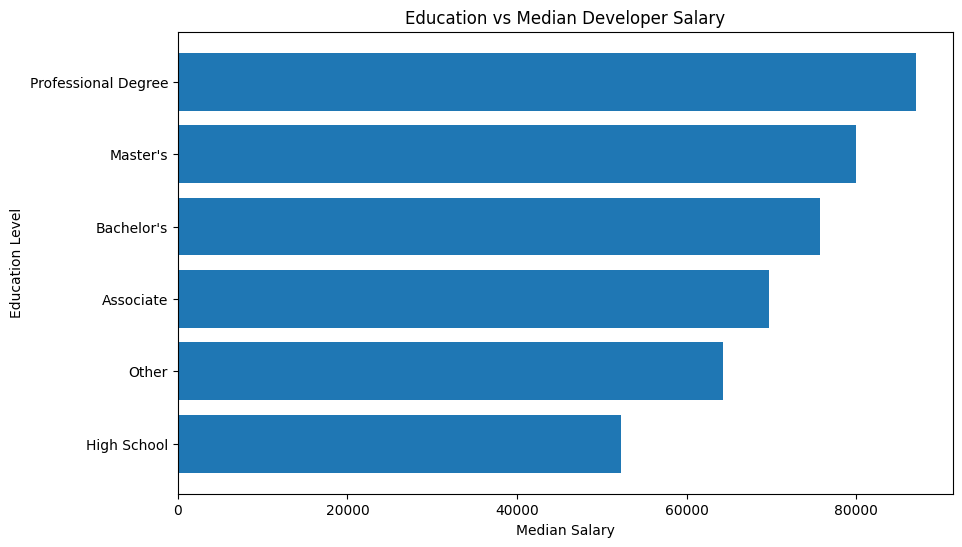

In [14]:
import matplotlib.pyplot as plt

df = education_salary_impact.collect().to_pandas()

plt.figure(figsize=(10, 6))
plt.barh(df["Education"], df["MedianSalary"])
plt.xlabel("Median Salary")
plt.ylabel("Education Level")
plt.title("Education vs Median Developer Salary")
plt.gca().invert_yaxis()
plt.show()

In [15]:
# Which technologies are associated with higher salaries?

# Languages

language_salary = (
    pl.scan_csv(file_path, infer_schema_length=100000)
    .select([
        pl.col("LanguageHaveWorkedWith"),

        pl.col("ConvertedCompYearly")
          .cast(pl.Float64, strict=False)
          .alias("Salary")
    ])
    .filter(
        pl.col("LanguageHaveWorkedWith").is_not_null() &
        pl.col("Salary").is_not_null()
    )
    .with_columns(
        pl.col("LanguageHaveWorkedWith")
          .str.split(";")
          .alias("Language")
    )
    .explode("Language")
    .group_by("Language")
    .agg([
        pl.col("Salary")
          .median()
          .alias("MedianSalary"),

        pl.len()
          .alias("Developers")
    ])
    .filter(pl.col("Developers") >= 50)
    .sort("MedianSalary", descending=True)
)

print(language_salary.head(20).collect())

shape: (20, 3)
┌────────────┬──────────────┬────────────┐
│ Language   ┆ MedianSalary ┆ Developers │
│ ---        ┆ ---          ┆ ---        │
│ str        ┆ f64          ┆ u32        │
╞════════════╪══════════════╪════════════╡
│ Ruby       ┆ 102961.0     ┆ 1550       │
│ Erlang     ┆ 100000.0     ┆ 314        │
│ Perl       ┆ 99886.5      ┆ 806        │
│ Elixir     ┆ 99194.0      ┆ 615        │
│ Scala      ┆ 96524.0      ┆ 600        │
│ …          ┆ …            ┆ …          │
│ TypeScript ┆ 79647.5      ┆ 10336      │
│ C#         ┆ 78616.0      ┆ 6397       │
│ Gleam      ┆ 77730.0      ┆ 209        │
│ Python     ┆ 76828.0      ┆ 12730      │
│ SQL        ┆ 76518.0      ┆ 13546      │
└────────────┴──────────────┴────────────┘


In [16]:
# Which technologies are associated with higher salaries?

# Databases

database_salary = (
    pl.scan_csv(file_path, infer_schema_length=100000)
    .select([
        "DatabaseHaveWorkedWith",

        pl.col("ConvertedCompYearly")
          .cast(pl.Float64, strict=False)
          .alias("Salary")
    ])
    .filter(
        pl.col("DatabaseHaveWorkedWith").is_not_null() &
        pl.col("Salary").is_not_null()
    )
    .with_columns(
        pl.col("DatabaseHaveWorkedWith")
          .str.split(";")
          .alias("Database")
    )
    .explode("Database")
    .group_by("Database")
    .agg([
        pl.col("Salary").median().alias("MedianSalary"),
        pl.len().alias("Developers")
    ])
    .filter(pl.col("Developers") >= 50)
    .sort("MedianSalary", descending=True)
)

print(database_salary.head(20).collect())

shape: (20, 3)
┌──────────────────────┬──────────────┬────────────┐
│ Database             ┆ MedianSalary ┆ Developers │
│ ---                  ┆ ---          ┆ ---        │
│ str                  ┆ f64          ┆ u32        │
╞══════════════════════╪══════════════╪════════════╡
│ Snowflake            ┆ 126306.0     ┆ 862        │
│ Amazon Redshift      ┆ 104825.5     ┆ 474        │
│ Databricks SQL       ┆ 104413.0     ┆ 700        │
│ Dynamodb             ┆ 102093.0     ┆ 2019       │
│ DuckDB               ┆ 100000.0     ┆ 634        │
│ …                    ┆ …            ┆ …          │
│ Microsoft SQL Server ┆ 77760.0      ┆ 5950       │
│ Neo4J                ┆ 76478.5      ┆ 496        │
│ H2                   ┆ 75410.0      ┆ 948        │
│ SQLite               ┆ 75320.0      ┆ 6839       │
│ IBM DB2              ┆ 71929.0      ┆ 446        │
└──────────────────────┴──────────────┴────────────┘


In [4]:
# How do remote and onsite jobs compare?

remote_salary = (
    pl.scan_csv(file_path, infer_schema_length=100000)
    .select([
        "RemoteWork",

        pl.col("ConvertedCompYearly")
          .cast(pl.Float64, strict=False)
          .alias("Salary")
    ])
    .filter(
        pl.col("RemoteWork").is_not_null() &
        pl.col("Salary").is_not_null()
    )
    .group_by("RemoteWork")
    .agg([
        pl.col("Salary")
          .median()
          .alias("MedianSalary"),

        pl.len()
          .alias("Respondents")
    ])
    .sort("MedianSalary", descending=True)
)

print(remote_salary.collect())

shape: (6, 3)
┌─────────────────────────────────┬──────────────┬─────────────┐
│ RemoteWork                      ┆ MedianSalary ┆ Respondents │
│ ---                             ┆ ---          ┆ ---         │
│ str                             ┆ f64          ┆ u32         │
╞═════════════════════════════════╪══════════════╪═════════════╡
│ Remote                          ┆ 100000.0     ┆ 1679        │
│ Hybrid (some in-person, leans … ┆ 84250.0      ┆ 891         │
│ Your choice (very flexible, yo… ┆ 83531.0      ┆ 648         │
│ Hybrid (some remote, leans hea… ┆ 81210.0      ┆ 937         │
│ NA                              ┆ 80127.0      ┆ 666         │
│ In-person                       ┆ 58007.0      ┆ 688         │
└─────────────────────────────────┴──────────────┴─────────────┘


In [6]:
# How does AI usage correlate with salary?

ai_salary = (
    pl.scan_csv(file_path, infer_schema_length=100000)
    .select([
        "LearnCodeAI",
        pl.col("ConvertedCompYearly")
          .cast(pl.Float64, strict=False)
          .alias("Salary")
    ])
    .filter(
        pl.col("LearnCodeAI").is_not_null() &
        pl.col("Salary").is_not_null()
    )
    .with_columns(
        pl.col("LearnCodeAI").str.split(";").alias("AIUsage")
    )
    .explode("AIUsage")
    .group_by("AIUsage")
    .agg([
        pl.col("Salary").median().alias("MedianSalary"),
        pl.len().alias("Respondents")
    ])
    .filter(pl.col("Respondents") >= 30)
    .sort("MedianSalary", descending=True)
)

print(ai_salary.collect())

shape: (6, 3)
┌─────────────────────────────────┬──────────────┬─────────────┐
│ AIUsage                         ┆ MedianSalary ┆ Respondents │
│ ---                             ┆ ---          ┆ ---         │
│ str                             ┆ f64          ┆ u32         │
╞═════════════════════════════════╪══════════════╪═════════════╡
│ Yes, I learned how to use AI-e… ┆ 81210.0      ┆ 9271        │
│ NA                              ┆ 76555.0      ┆ 30          │
│ No, I learned something that w… ┆ 72958.0      ┆ 2595        │
│ Yes, I learned how to use AI-e… ┆ 72815.0      ┆ 7302        │
│ No, I didn't spend time learni… ┆ 70794.0      ┆ 2245        │
│ No, I learned something that w… ┆ 69609.0      ┆ 2504        │
└─────────────────────────────────┴──────────────┴─────────────┘
